# Рубежный контроль №1 - Отчёт

**Имя** -Фон Маунг Хтве  
**Группа** - ИУ5И-23М  
**Номер в списке** - 2  
**Номер варианта** - 17  

**Тема** - Методы обработки данных (Methods of Data Processing)

## О наборе данных

- **Название набора данных** - California Housing dataset
- **Источник** - модуль datasets библиотеки scikit-learn
- **Количество строк** - 20 640
- **Количество столбцов** - 8 (признаки) + 1 (целевая переменная)
- **Описание столбцов**
  - MedInc - медианный доход в районе
  - HouseAge - медианный возраст дома
  - AveRooms - среднее количество комнат
  - AveBedrms - среднее количество спален
  - Population - численность населения
  - AveOccup - средняя занятость домохозяйства
  - Latitude - широта
  - Longitude - долгота
  - **Целевая переменная (y)** - MedHouseVal (медианная стоимость дома)

In [3]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import SelectPercentile, mutual_info_regression

# Отключение предупреждений (опционально)
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки успешно импортированы.")

Библиотеки успешно импортированы.


In [4]:
# Загрузка набора данных California Housing
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Сохранение целевой переменной (target) в переменную y
y = housing.target

# Просмотр первых 5 строк набора данных
print("Первые 5 строк набора данных:")
print(df.head())

print("\nФорма (размерность) набора данных:", df.shape)

Первые 5 строк набора данных:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Форма (размерность) набора данных: (20640, 8)


Исходные данные (первые 10 значений):
0    8.3252
1    8.3014
2    7.2574
3    5.6431
4    3.8462
5    4.0368
6    3.6591
7    3.1200
8    2.0804
9    3.6912
Name: MedInc, dtype: float64

После преобразования Йео-Джонсона (первые 10 значений):
0    1.903289
1    1.897081
2    1.604361
3    1.051321
4    0.205878
5    0.312151
6    0.096567
7   -0.250386
8   -1.105344
9    0.115691
Name: MedInc_YeoJohnson, dtype: float64


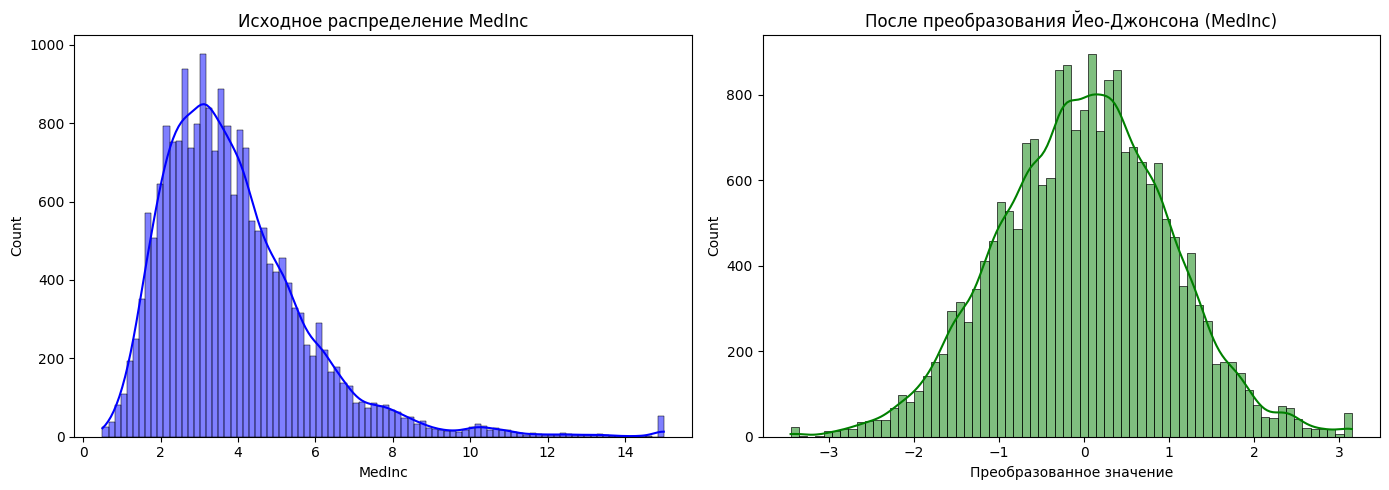

In [5]:
# Задача №17: Преобразование Йео-Джонсона

# Выбор столбца (например, MedInc)
column_name = 'MedInc'
original_data = df[column_name].copy()

# Выполнение преобразования Йео-Джонсона
yj_transformer = PowerTransformer(method='yeo-johnson')
transformed_data = yj_transformer.fit_transform(df[[column_name]])

# Добавление результата в DataFrame
df['MedInc_YeoJohnson'] = transformed_data

# Вывод результатов
print("Исходные данные (первые 10 значений):")
print(original_data.head(10))
print("\nПосле преобразования Йео-Джонсона (первые 10 значений):")
print(df['MedInc_YeoJohnson'].head(10))

# Построение графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение исходных данных
sns.histplot(original_data, kde=True, ax=axes[0], color='blue')
axes[0].set_title(f'Исходное распределение {column_name}')
axes[0].set_xlabel(column_name)

# После преобразования Йео-Джонсона
sns.histplot(df['MedInc_YeoJohnson'], kde=True, ax=axes[1], color='green')
axes[1].set_title(f'После преобразования Йео-Джонсона ({column_name})')
axes[1].set_xlabel('Преобразованное значение')

plt.tight_layout()
plt.show()

In [6]:
# Задача №37: Отбор признаков с помощью SelectPercentile (5%) на основе взаимной информации

X = df[housing.feature_names]  # Только исходные 8 признаков (без преобразованных)

# Настройка SelectPercentile с 5%
selector = SelectPercentile(score_func=mutual_info_regression, percentile=5)
selector.fit(X, y)

# Получение отобранных признаков
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
mi_scores = selector.scores_

print("Общее количество признаков:", X.shape[1])
print("Количество отобранных признаков (5%):", selected_mask.sum())
print("\nОтобранные признаки (top 5%):")
for feat in selected_features:
    print(f"  ✓ {feat}")

# Отображение оценок взаимной информации
scores_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores,
    'Selected': selected_mask
}).sort_values('MI_Score', ascending=False)

print("\nОценки взаимной информации (от наибольшей к наименьшей):")
print(scores_df)

Общее количество признаков: 8
Количество отобранных признаков (5%): 1

Отобранные признаки (top 5%):
  ✓ Longitude

Оценки взаимной информации (от наибольшей к наименьшей):
      Feature  MI_Score  Selected
7   Longitude  0.401900      True
0      MedInc  0.387562     False
6    Latitude  0.370515     False
2    AveRooms  0.103171     False
5    AveOccup  0.073063     False
1    HouseAge  0.031995     False
3   AveBedrms  0.024132     False
4  Population  0.021245     False


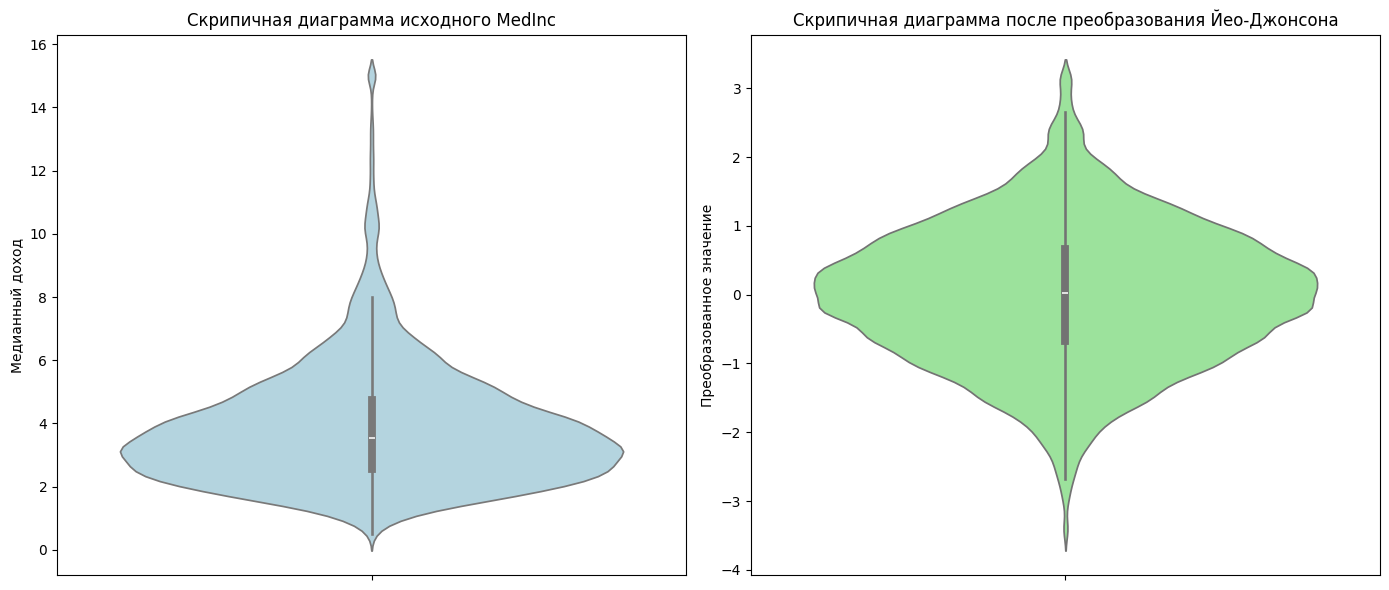

In [7]:
# Скрипичная диаграмма для группы ИУ5И-24М

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Скрипичная диаграмма - исходный MedInc
sns.violinplot(y=df['MedInc'], ax=axes[0], color='lightblue')
axes[0].set_title('Скрипичная диаграмма исходного MedInc')
axes[0].set_ylabel('Медианный доход')

# Скрипичная диаграмма - после преобразования Йео-Джонсона
sns.violinplot(y=df['MedInc_YeoJohnson'], ax=axes[1], color='lightgreen')
axes[1].set_title('Скрипичная диаграмма после преобразования Йео-Джонсона')
axes[1].set_ylabel('Преобразованное значение')

plt.tight_layout()
plt.show()

## Заключение (Conclusion)

1. **Преобразование Йео-Джонсона** - Исходный столбец MedInc имеет правостороннее (right-skewed) распределение.
   После преобразования Йео-Джонсона распределение становится ближе к нормальному распределению (normal distribution).

2. **Отбор признаков** - Согласно взаимной информации (Mutual Information), MedInc (медианный доход) является наиболее важным признаком для прогнозирования стоимости дома.
   В соответствии с заданным порогом 5% был выбран только один признак - MedInc.

3. **Скрипичная диаграмма (Violin Plot)** - На диаграмме сравниваются распределения, медианные значения и плотности исходных и преобразованных данных.